In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import matplotlib.ticker as ticker
import seaborn as sns

## Preprocessing

In [2]:
df = pd.read_csv('data/hatla2ee_scraped_data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14277 entries, 0 to 14276
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Listing ID    14277 non-null  int64  
 1   Title         4966 non-null   str    
 2   Price         14277 non-null  int64  
 3   Make          14277 non-null  str    
 4   Model         14277 non-null  str    
 5   Year          14277 non-null  int64  
 6   Mileage (km)  11705 non-null  float64
 7   Color         14275 non-null  str    
 8   Transmission  14275 non-null  str    
 9   Fuel Type     14275 non-null  str    
 10  Body Type     14152 non-null  str    
 11  Condition     14277 non-null  str    
 12  Imported      3919 non-null   str    
 13  Taxi          4455 non-null   str    
 14  City          14277 non-null  str    
 15  Governorate   14275 non-null  str    
 16  Seller Phone  14276 non-null  float64
 17  Has WhatsApp  12852 non-null  str    
 18  Date Listed   14277 non-null  str    

In [3]:
df.drop(
    columns=[
        "Sold At",
        "Has WhatsApp",
        "Seller Phone",
        "Taxi",
        "Imported",
        "Title",
        "Listing ID",
        "Date Listed",
        "Item URL",
    ],
    inplace=True,
)

In [4]:
df.iloc[1]

Price                                                      150000
Make                                                       Daewoo
Model                                                       Matiz
Year                                                         1999
Mileage (km)                                                180.0
Color           {'id': 25, 'slug': 'other', 'label': 'Other', ...
Transmission    {'id': 26, 'slug': 'manual', 'label': 'Manual'...
Fuel Type       {'id': 32, 'slug': 'gas', 'label': 'Gas', 'val...
Body Type       {'id': 122, 'slug': 'hatchback', 'label': 'Hat...
Condition       {'id': 119, 'slug': 'used', 'label': 'Used', '...
City                                                     Damietta
Governorate                                              Damietta
Name: 1, dtype: object

In [5]:
df.dropna(inplace=True)
df = df.drop_duplicates()

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 11481 entries, 0 to 14276
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         11481 non-null  int64  
 1   Make          11481 non-null  str    
 2   Model         11481 non-null  str    
 3   Year          11481 non-null  int64  
 4   Mileage (km)  11481 non-null  float64
 5   Color         11481 non-null  str    
 6   Transmission  11481 non-null  str    
 7   Fuel Type     11481 non-null  str    
 8   Body Type     11481 non-null  str    
 9   Condition     11481 non-null  str    
 10  City          11481 non-null  str    
 11  Governorate   11481 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 8.1 MB


In [7]:
dict_cols = ["Color", "Transmission", "Fuel Type", "Body Type", "Condition"]

for col in dict_cols:
    df[col] = df[col].apply(
        lambda x: ast.literal_eval(x)["label"] if isinstance(x, str) else x["label"]
    )

In [8]:
df.iloc[1]

Price              150000
Make               Daewoo
Model               Matiz
Year                 1999
Mileage (km)        180.0
Color               Other
Transmission       Manual
Fuel Type             Gas
Body Type       Hatchback
Condition            Used
City             Damietta
Governorate      Damietta
Name: 1, dtype: object

In [9]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Mileage (km)"] = pd.to_numeric(df["Mileage (km)"], errors="coerce")


In [10]:
# Remove scraping garbage: placeholder prices/mileages and impossible years
df = df[
    (df["Price"].between(20000, 15_000_000))
    & (df["Mileage (km)"] <= 500_000)
    & (df["Year"].between(1986, 2026))
]

In [11]:
df.head()

,Price,Make,Model,Year,Mileage (km),Color,Transmission,Fuel Type,Body Type,Condition,City,Governorate
0,1950000,Audi,Q3,2021,56000.0,White,Automatic,Gas,SUV,Used,Tagamo3 - New Cairo,Cairo
1,150000,Daewoo,Matiz,1999,180.0,Other,Manual,Gas,Hatchback,Used,Damietta,Damietta
2,2700000,Mercedes,C 180,2023,55000.0,Gray,Automatic,Gas,Sedan,Used,Tagamo3 - New Cairo,Cairo
3,2150000,Mini,Cooper,2023,6000.0,Red,Automatic,Gas,Convertible,Used,Tagamo3 - New Cairo,Cairo
4,1300000,Jetour,X90,2024,40000.0,Black,Automatic,Gas,MPV,Used,Nasr city,Cairo


## EDA

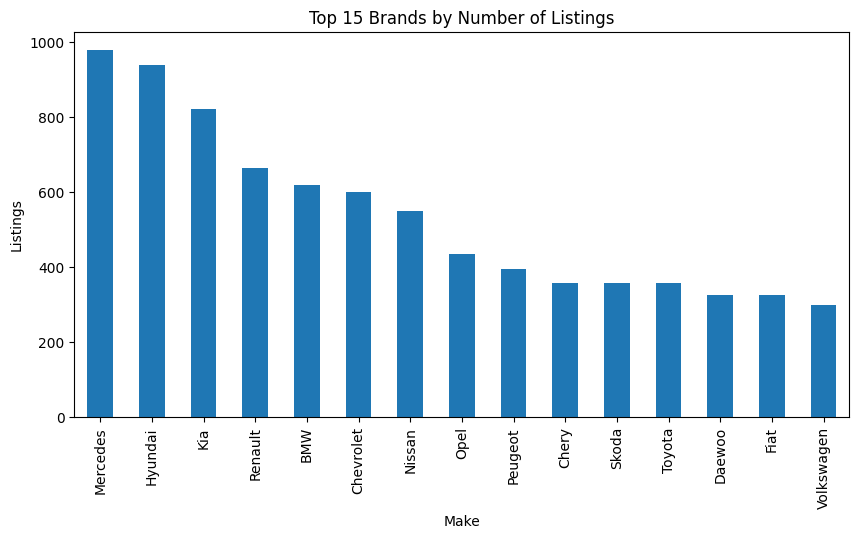

In [12]:
# Which brands dominate the online used-car market?
brand_counts = df["Make"].value_counts().head(15)

brand_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Top 15 Brands by Number of Listings")
plt.ylabel("Listings")
plt.show()

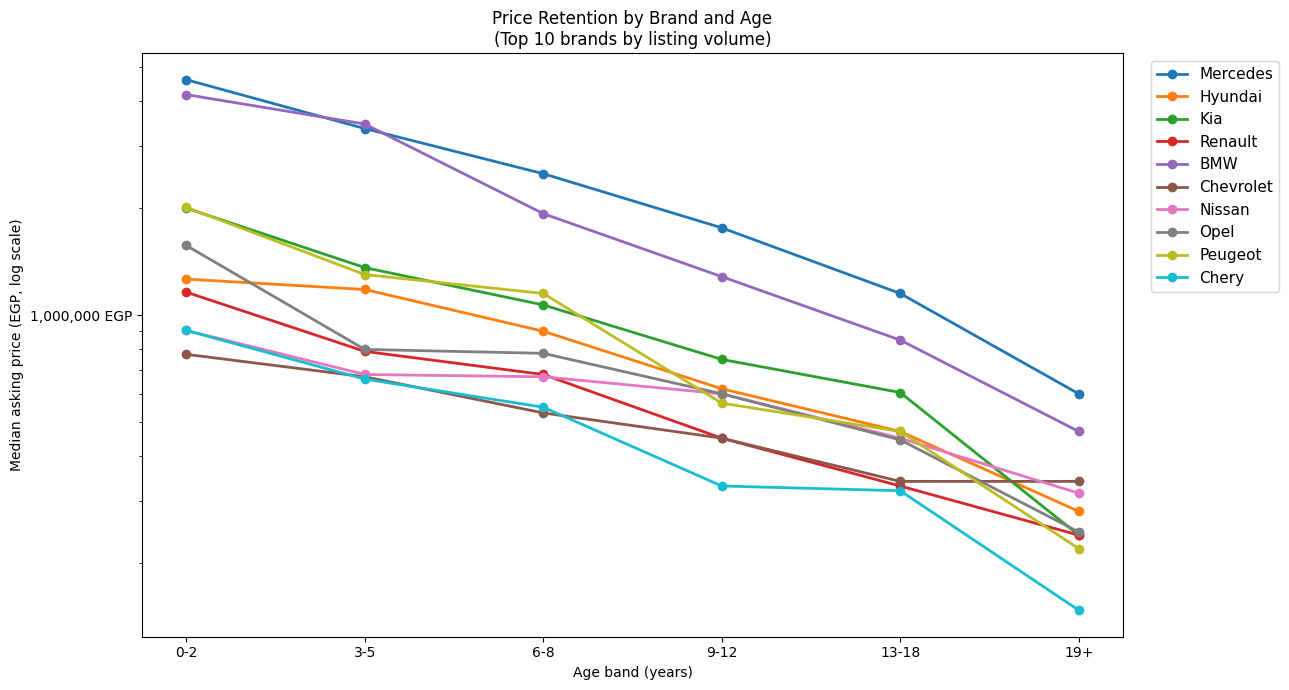

In [13]:
# Which brands retain the highest asking prices as vehicles age?
df["Age"] = 2026 - df["Year"]
top_brands = brand_counts.head(10).index
sub = df[df["Make"].isin(top_brands)].copy()
sub["age_band"] = pd.cut(
    sub["Age"],
    bins=[-1, 2, 5, 8, 12, 18, 40],
    labels=["0-2", "3-5", "6-8", "9-12", "13-18", "19+"],
)

med = sub.groupby(["Make", "age_band"], observed=True)["Price"].median().reset_index()

fig, ax = plt.subplots(figsize=(13, 7))
for brand in top_brands:
    d = med[med["Make"] == brand]
    ax.plot(d["age_band"].astype(str), d["Price"], marker="o", label=brand, linewidth=2)
ax.set_yscale("log")
egp_formatter = ticker.StrMethodFormatter('{x:,.0f} EGP')
ax.yaxis.set_major_formatter(egp_formatter)
ax.set_xlabel("Age band (years)")
ax.set_ylabel("Median asking price (EGP, log scale)")
ax.set_title("Price Retention by Brand and Age\n(Top 10 brands by listing volume)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=11)
plt.tight_layout()
plt.show()

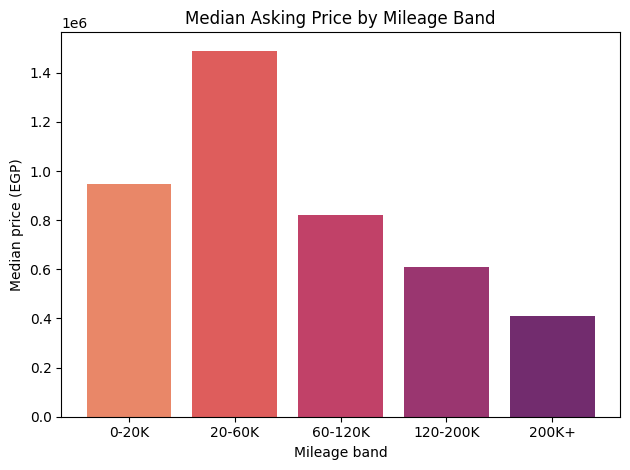

In [14]:
# How does mileage affect asking price?
df["mileage_band"] = pd.cut(
    df["Mileage (km)"],
    bins=[-1, 20000, 60000, 120000, 200000, 500000],
    labels=["0-20K", "20-60K", "60-120K", "120-200K", "200K+"],
)
band_med = df.groupby("mileage_band", observed=True)["Price"].median()
plt.bar(band_med.index.astype(str), band_med.values, color=sns.color_palette("flare", 5))
plt.ylabel("Median price (EGP)")
plt.xlabel("Mileage band")
plt.title("Median Asking Price by Mileage Band")
plt.tight_layout()
plt.show()

In [15]:
print("Correlation(mileage, price) within age bands:")
for ab in sub["age_band"].cat.categories:
    d = df[
        pd.cut(
            df["Age"],
            bins=[-1, 2, 5, 8, 12, 18, 40],
            labels=["0-2", "3-5", "6-8", "9-12", "13-18", "19+"],
        )
        == ab
    ]
    if len(d) > 30:
        print(f"  {ab}: r={d['Mileage (km)'].corr(d['Price']):.2f}")

Correlation(mileage, price) within age bands:
  0-2: r=-0.21
  3-5: r=-0.35
  6-8: r=-0.24
  9-12: r=-0.14
  13-18: r=-0.02
  19+: r=0.08


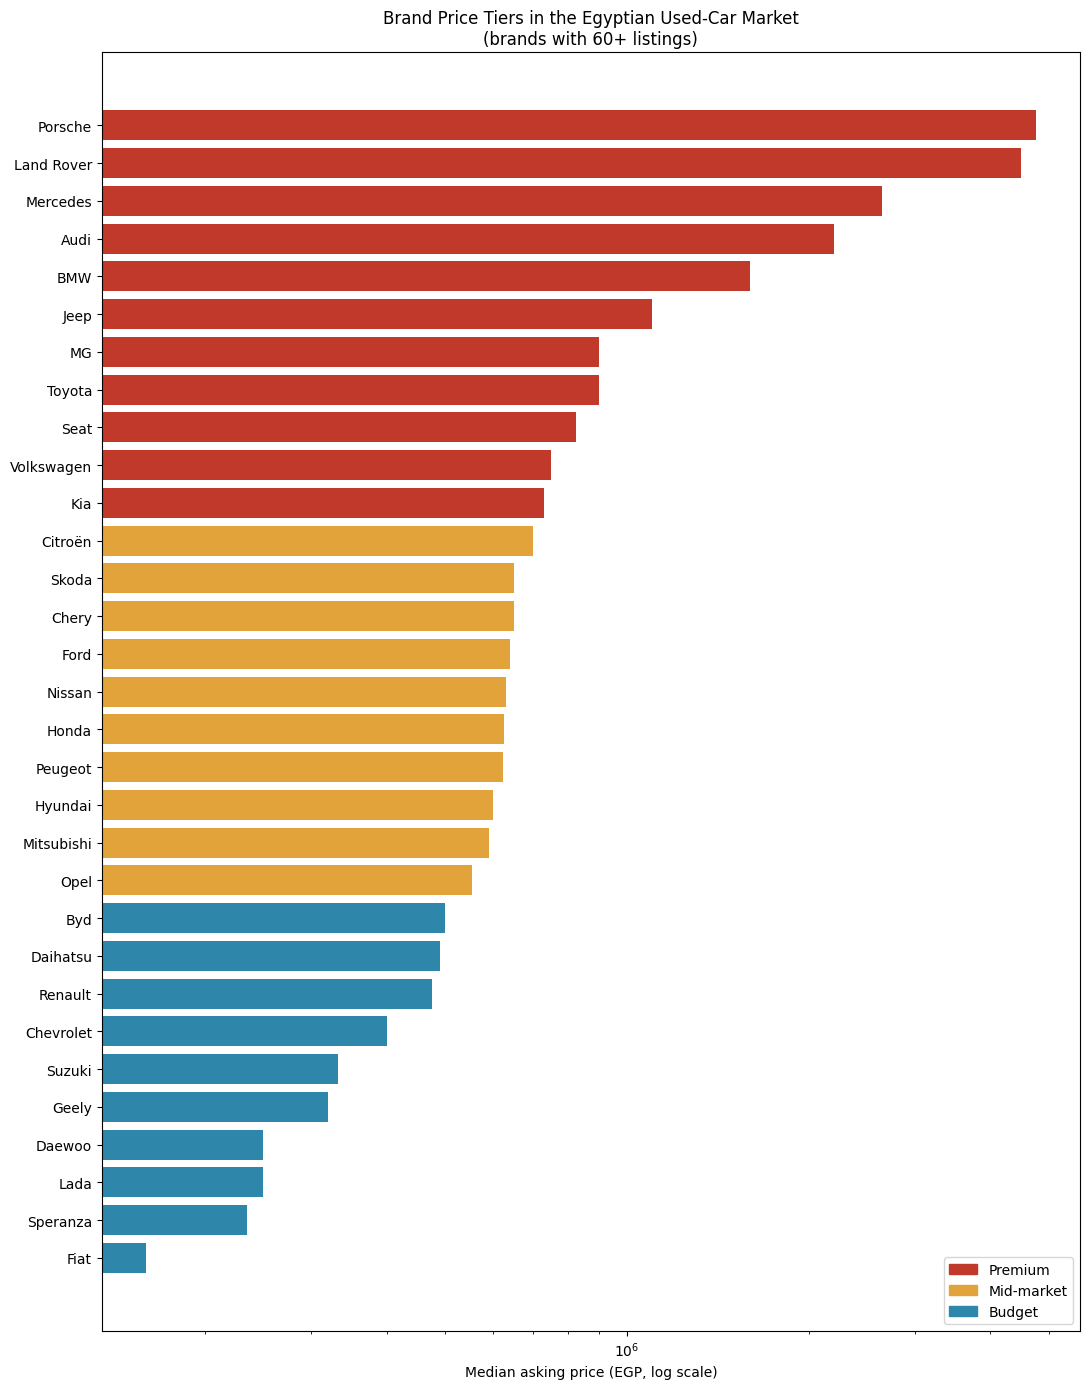


Brand tiers:
            median_price    n        tier
Make                                     
Porsche        4750000.0   61     Premium
Land Rover     4500000.0  130     Premium
Mercedes       2650000.0  979     Premium
Audi           2200000.0   99     Premium
BMW            1600000.0  618     Premium
Jeep           1100000.0  220     Premium
MG              900000.0  292     Premium
Toyota          900000.0  357     Premium
Seat            825000.0  116     Premium
Volkswagen      750000.0  297     Premium
Kia             730000.0  821     Premium
Citroën         700000.0  143  Mid-market
Skoda           650000.0  358  Mid-market
Chery           650000.0  358  Mid-market
Ford            640000.0  112  Mid-market
Nissan          630000.0  550  Mid-market
Honda           625000.0   85  Mid-market
Peugeot         622500.0  394  Mid-market
Hyundai         600000.0  938  Mid-market
Mitsubishi      590000.0  276  Mid-market
Opel            555000.0  435  Mid-market
Byd             5000

In [16]:
# What are the premium, mid-market, and budget brands?
solid_brands = df["Make"].value_counts()
solid_brands = solid_brands[solid_brands >= 60].index
solid = df[df["Make"].isin(solid_brands)]
brand_stats = (
    solid.groupby("Make")
    .agg(
        median_price=("Price", "median"),
        mean_price=("Price", "mean"),
        n=("Price", "size"),
    )
    .sort_values("median_price", ascending=False)
)

q1, q2 = brand_stats["median_price"].quantile([0.66, 0.33])


def tier(p):
    if p >= q1:
        return "Premium"
    if p >= q2:
        return "Mid-market"
    return "Budget"


brand_stats["tier"] = brand_stats["median_price"].apply(tier)

tier_colors = {"Premium": "#C0392B", "Mid-market": "#E2A33B", "Budget": "#2E86AB"}
fig, ax = plt.subplots(figsize=(11, 14))
order = brand_stats.sort_values("median_price", ascending=True)
ax.barh(
    order.index, order["median_price"], color=[tier_colors[t] for t in order["tier"]]
)
ax.set_xscale("log")

ax.set_xlabel("Median asking price (EGP, log scale)")
ax.set_title(
    "Brand Price Tiers in the Egyptian Used-Car Market\n(brands with 60+ listings)"
)
from matplotlib.patches import Patch
handles = [Patch(color=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=handles, loc="lower right")
plt.tight_layout()
plt.show()
print("\nBrand tiers:")
print(brand_stats[["median_price", "n", "tier"]])

In [ ]:
df.to_csv("data/hatla2ee_scraped_data_cleaned.csv", index=False)